In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes
mpl.rc('font', family='Arial')
mpl.rc('font',size = 8)
mpl.rc('mathtext',fontset = 'stix')
mpl.rc('xtick', labelsize=6)
mpl.rc('ytick', labelsize=6)
# mpl.rc('xtick', labelsize=4)
# mpl.rc('ytick', labelsize=4)
mpl.rc('axes', labelsize=8)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=8)
mpl.rc('axes', linewidth=0.5)
figsavepath = "../../Elements/MicroBeam"

C:\Users\TengMa\AppData\Local\Temp\ipykernel_35052\1995258559.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap("tab10")


In [3]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
datadir = r'C:\Users\TengMa\OneDrive\POLIMI\1. MEMS SINDy\wetransfer_beam-data_2024-07-16_0827'
dataname = 'sindy_beam_S_FRF_not_unif.mat'
datafile = "%s/%s"%(datadir, dataname)
P = "%s/%s"%(datadir, 'sindy_beam_I_FRF_not_unif.mat')
POM = "%s/%s"%(datadir, 'POM.mat')
import h5py
with h5py.File(datafile, 'r') as file:
    data = np.array(file['S'])
with h5py.File(P, 'r') as file:
    p = np.array(file['I'])

In [4]:
timestamp = 22500
timeeffect = 22500
Modes = 3
node = 5488
import scipy
import pandas as pd
Modeshape = scipy.io.loadmat(POM)["POM"]
POM_1 = np.zeros(Modes)
for i in range(Modes):
    # print(f[node,i])
    POM_1[i] = Modeshape[node,i]
print(POM_1)

[0.03545827 0.02839143 0.00044787]


0.5510469810602161 0.25
12.822477915915421
0.5510469810602161 1.3787432990884114


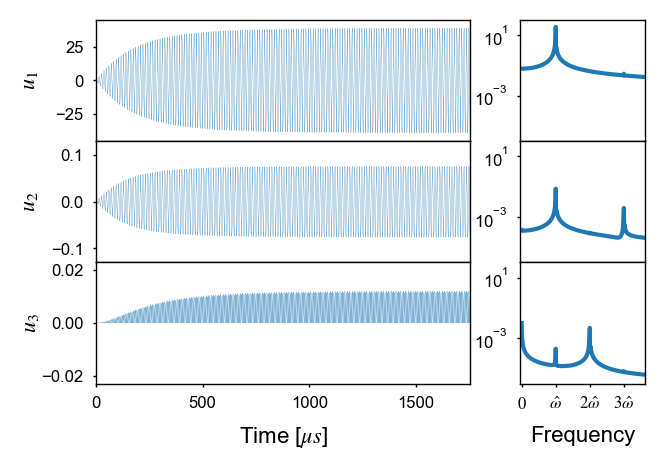

In [40]:
num = 14
start = num*timestamp+1
end = (num+1)*timestamp
F_omega1 = p[1,start]
F_amplitude = p[2,start]
print(F_omega1, F_amplitude)

t = p[0,start:start+timeeffect]
F = np.cos(F_omega1*t)
Fs = timeeffect/(t[-1]-t[0])
print(Fs)
ylabels = ['$u_1$','$u_2$','$u_3$','$u_4']
ylabels_pad = [5.5,3.8,0,0]
ylims = [(-45,45),(-0.13,0.13),(-0.023,0.023),(-0.002,0.002)]
fig, axes = plt.subplots(Modes,2,figsize = (9/2.54,6/2.54),  gridspec_kw={'width_ratios': [3, 1]},dpi = 200)
plt.subplots_adjust(hspace = 0)
for mode in range(Modes):
    ax = axes[mode][0]
    
    y = data[mode,start:start+timeeffect]
    ax.plot(t,y,lw = 0.1)
    ax.set_ylabel(ylabels[mode], labelpad = ylabels_pad[mode])
    ax.tick_params(direction='out',width = 0.5,length = 1)
    ax.set_xlim(0,t[-1])
    ax.set_ylim(ylims[mode])
    ax.set_xlabel('Time [$\mu s$]',labelpad = 5)
    ax = axes[mode][1]
    N = len(y)
    yf = fft(y)
    xf = fftfreq(N, (t[-1]-t[0])/timestamp)[:N//2]
    ax.plot(xf*2*np.pi, 2.0/N * np.abs(yf[0:N//2]))
    ax.set_xlim(-0.02,2)
    ax.set_xlabel('Frequency',labelpad = 5)
    ax.set_yscale('log')
    ax.tick_params(direction='out',width = 0.5,length = 1)
    ax.set_ylim(1e-6,100)
    ax.set_yticks([1e-3,1e1])
    ax.set_xticks([0,F_omega1,2*F_omega1,3*F_omega1])
    ax.set_xticklabels(['$0$',r'$\hat{\omega}$',r'$2\hat{\omega}$',r'$3\hat{\omega}$'])
    if mode != 2:
        axes[mode][0].set_xticks([])
        axes[mode][1].set_xticks([])
        axes[mode][0].set_xlabel("")
        axes[mode][1].set_xlabel("")
orbit = np.sum(data[:Modes,start:start+timeeffect].T * POM_1, axis = 1)
Train_FRF = (np.max(orbit) - np.min(orbit))/2
Train_FREQ = F_omega1
print(Train_FREQ,Train_FRF)
plt.savefig("../../Elements/MicroBeam/OriginPOD_%d.svg"%num,dpi = 300,transparent = True,bbox_inches="tight")

In [6]:
import importlib
import sys
sys.path.append("../")
import EvLOWN
importlib.reload(EvLOWN)  # 重新载入
library = [
    lambda x:x[0],
    lambda x:x[0]*x[0],
    lambda x:x[0]*x[0]*x[0],
    lambda x:x[1],
    lambda x:x[1]*x[1],
    lambda x:x[1]*x[1]*x[1],
    lambda x:x[2],
    lambda x:x[2]*x[2],
    lambda x:x[2]*x[2]*x[2],
    lambda x:x[3],
    lambda x:x[3]*x[3],
    lambda x:x[3]*x[3]*x[3],
    lambda x:x[4],
    lambda x:x[4]*x[4],
    lambda x:x[4]*x[4]*x[4],
    lambda x:x[5],
    lambda x:x[5]*x[5],
    lambda x:x[5]*x[5]*x[5],
    # lambda x:x[6],
    # lambda x:x[6]*x[6],
    # lambda x:x[6]*x[6]*x[6],
    # lambda x:x[7],
    # lambda x:x[7]*x[7],
    # lambda x:x[7]*x[7]*x[7],
]
library_name = [
    lambda x:x[0],
    lambda x:x[0]+x[0],
    lambda x:x[0]+x[0]+x[0],
    lambda x:x[0]+x[0]+x[0]+x[0],
    lambda x:x[0]+x[0]+x[0]+x[0]+x[0],
    lambda x:x[1],
    lambda x:x[1]+x[1],
    lambda x:x[1]+x[1]+x[1],
    lambda x:x[1]+x[1]+x[1]+x[1],
    lambda x:x[1]+x[1]+x[1]+x[1]+x[1],
    lambda x:x[0]+x[1],
    lambda x:x[0]+x[0]+x[1],
    lambda x:x[0]+x[1]+x[1],
    lambda x:x[0]+x[0]+x[0]+x[1],
    lambda x:x[0]+x[0]+x[1]+x[1],
    lambda x:x[0]+x[1]+x[1]+x[1],
    lambda x:x[0]+x[0]+x[0]+x[0]+x[1],
    lambda x:x[0]+x[0]+x[0]+x[1]+x[1],
    lambda x:x[0]+x[0]+x[1]+x[1]+x[1],
    lambda x:x[0]+x[1]+x[1]+x[1]+x[1],
]
dim = 3
model_EvLOWN = EvLOWN.WeakNOForce(dim,library,library_name)

In [7]:
print(Modes)
Xis = np.zeros([len(library)+1,Modes])
# fig, axes = plt.subplots(Modes,2,figsize = (4,Modes*0.5),dpi = 200)
# plt.subplots_adjust(hspace = 0, wspace = 0.15)
displacement = data[:Modes,start:start+timeeffect]
velocity = np.zeros([Modes,timeeffect])
for mode in range(Modes):
    velocity[mode] = np.gradient(data[mode,start:start+timeeffect],t)
# velocity = np.gradient(data[:Modes,start:start+timeeffect],t,axis = 0)
model_EvLOWN.Get_frequency(displacement.T,velocity.T,t[:])
print(model_EvLOWN.frequencys)
model_EvLOWN.frequencys[1] = model_EvLOWN.frequencys[0]
model_EvLOWN.frequencys[2] = model_EvLOWN.frequencys[0]
model_EvLOWN.Get_Evolution(order = [0,1,2])
model_EvLOWN.Library_rebuild(F[:])
T_period = 2*np.pi/model_EvLOWN.frequencys[0]
num_period = int((t[-1] - t[0]) // T_period)
t_periods = np.linspace(0,t[-1], num_period+1)


3
[0.54826113 0.54826113 0.        ]


In [17]:
orders = [[1,2],[1,2],[0,3,4]]
model_EvLOWN.optimize(orders = orders, startcycle = 1, endcycle=10,sparse_threshold=0.05, stop_tolerance=0.03)
print(model_EvLOWN.Xi)

start:1.43770
Round 0, step: 0.05854, now: 0.94146, selected: 18
Round 1, step: 0.44643, now: 0.49503, selected: 3
Round 2, step: 0.45692, now: 0.03811, selected: 2
Round 3, step: 0.03405, now: 0.00406, selected: 0
start:0.00306
Round 0, step: 0.05601, now: 0.94399, selected: 18
Round 1, step: 0.46827, now: 0.47572, selected: 3
Round 2, step: 0.43158, now: 0.04414, selected: 2
Round 3, step: 0.01450, now: 0.02964, selected: 0
start:0.05871
Round 0, step: 0.38213, now: 0.61787, selected: 4
Round 1, step: 0.61337, now: 0.00450, selected: 1
[[-7.90548496e-04  0.00000000e+00  2.73047251e-06  1.09983506e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00 -2.37709979e-01]
 [-1.46818043e-06  0.00000000e+00  5.45348137e-09  2.45030047e-05
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.0000

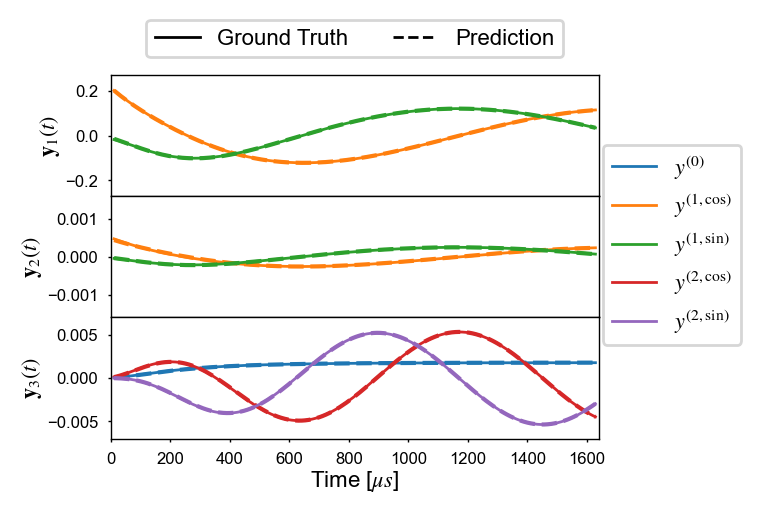

In [41]:
stp = 1
enp = 10
Omegaidxs = [0,6,12,18]
Xis = np.zeros([len(library)+1, Modes])
fig, axes = plt.subplots(Modes,1,figsize = (8/2.54,6/2.54),dpi = 200)
plt.subplots_adjust(hspace = 0)
ylims = [(-0.27,0.27),(-0.0016,0.0016),(-0.007,0.007),(-0.007,0.007)]
legends = ['$y^{(0)}$','$y^{(1,\cos)}$','$y^{(1,\sin)}$','$y^{(2,\cos)}$','$y^{(2,\sin)}$']
for d in range(Modes): 
    Xi = model_EvLOWN.Xi[d]
    # Xi[-1] = Xi[-1]/F_amplitude
    Xis[:,d] = Xi
    Xis[Omegaidxs[d],d] +=model_EvLOWN.frequencys[0]**2
    Xis[-1,d] = Xis[-1,d]/F_amplitude*2
    # for d in range(3):
    #     ax = axes[d]
    ax = axes[d]
    ax.set_xlabel('Time [$\mu s$]')
    if d!=2:
        ax.set_xticks([])
        ax.set_xlabel("")
    ax.set_xlim(0,t_periods[-1-enp])
    ax.set_ylim(ylims[d])
    ax.set_ylabel(r'$\mathbf{y}_%d(t)$'%(d+1))
    ax.tick_params(direction='out',width = 0.5,length = 1)
    if d == 0:
        for i in range(5):
            ax.plot([-1,-1], [-1,-1] ,color = colors[i],lw = 1, label = legends[i])
        ax.legend(loc = 'center',bbox_to_anchor = (1.15,-0.4))
    if d == 1:
        ax.plot([-1,-1], [-1,-1] ,color = 'black',lw = 1, label = 'Ground Truth')
        ax.plot([-1,-1], [-1,-1] ,color = 'black',lw = 1, ls = '--', label = 'Prediction')
        ax.legend(ncol = 2,loc = 'center',bbox_to_anchor = (0.5,2.3))
    for i in orders[d]:
        ax.plot(t_periods[stp:-enp-1],model_EvLOWN.dot[d][stp:-enp,i],color = colors[i],lw = 1)
        ax.plot(t_periods[stp:-enp-1],np.sum(model_EvLOWN.Phi[d][stp:-enp,i,:]*Xi, axis = 1),color = colors[i],ls = '--',lw = 1.5)

plt.savefig("../../Elements/MicroBeam/Slowvarying_%d.svg"%num,dpi = 300,transparent = True,bbox_inches="tight")

In [42]:
print(Xis)

[[ 2.99799714e-01 -1.46818043e-06  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  2.40226835e-06]
 [ 2.73047251e-06  5.45348137e-09  0.00000000e+00]
 [ 1.09983506e-02  2.45030047e-05  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -1.57449655e-05]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  3.00590262e-01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  3.00590262e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.90167983e+00 -4.20160475e-03  0.00000000e+00]]


In [ ]:
### import util
importlib.reload(util)  # 重新载入
library_matlab = [
    'u1','u1^2','u1^3','v1','v1^2','v1^3',
    'u2','u2^2','u2^3','v2','v2^2','v2^3',
    'u3','u3^2','u3^3','v3','v3^2','v3^3',
    'A*c'
]
util.generate_beam_from_library(
    func_name = "Beam_POM3_%d"%num,
    out_path = "../Matcont_solver/models/MicroBeam/Beam_POM3_%d.m"%num,
    n_dof = Modes,
    library = library_matlab,
    coef = -1*np.array(Xis),
    tol = 1e-12
    
)
util.append_coef_only_csv(
    csv_path = "Beam_coef.csv",
    library = library_matlab,
    coef = -1*np.array(Xis),
    eq_names = ['v1','v2','v3'],
    idx = num,
    tol = 1e-13
)


In [21]:
def ROM_Beam(x,t):
    dxdt = np.zeros(len(x))
    for d in range(Modes):
        dxdt[d*2] = x[d*2+1]
        for i in range(len(library)):
            dxdt[d*2+1] -= library[i](x)*Xis[i,d]
        dxdt[d*2+1] -= np.cos(F_omega1*t)*Xis[-1,d]*F_amplitude/2
    return dxdt


x0 = np.zeros(Modes*2)
x = odeint(ROM_Beam, x0, t)

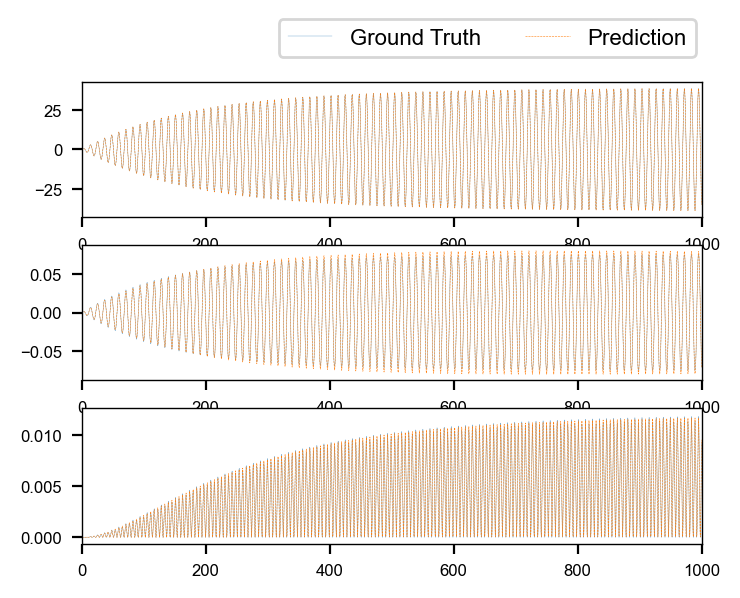

In [22]:
fig, axes = plt.subplots(Modes,1,figsize = (4,Modes*1),dpi = 200)
for i in range(Modes):
    ax = axes[i]
    ax.plot(t, data[i, start:start+timeeffect], lw = 0.1,label = 'Ground Truth')
    ax.plot(t, x[:,i*2],lw = 0.2, ls = '--', label = 'Prediction')
    ax.set_xlim(0,1000)
    if i == 0:
        ax.legend(ncol = 2, bbox_to_anchor = (0.3,1.1))

In [137]:
datadir = r'C:\Users\TengMa\OneDrive\POLIMI\1. MEMS SINDy\wetransfer_beam-data_2024-07-16_0827'
POM = "%s/%s"%(datadir, 'POM.mat')
import h5py
import scipy
import pandas as pd
Modeshape = scipy.io.loadmat(POM)["POM"]
timestamp = 22500
timeeffect = 22500

In [138]:

num = int(len(p[2,:])/timestamp)
Omegas_FOM = []
Amplitudes_FOM = []
# responses_FOM = np.zeros(num)
As = [0.0938,0.125,0.1562,0.1875,0.2188,0.25,0.2812,0.3125,0.375,0.5,0.625,0.75]
for i in range(len(AFs)):
    file = "../../Validation/MicroBeam/F_%.4f.csv"%AFs[i]
    data_FOM = pd.read_csv(file, header = None)
    Omegas_FOM.append(data_FOM[0])
    Amplitudes_FOM.append(data_FOM[1])
    
Modes = 3
POM_1 = np.zeros(Modes)
for i in range(Modes):
    # print(f[node,i])
    POM_1[i] = Modeshape[node,i]
print(POM_1)


NameError: name 'AFs' is not defined

In [155]:
# MATCONT 求解ROM
import os
import numpy as np
import matlab.engine
from tqdm.notebook import tqdm

PROJECT = r"../matcont_solver/"   # 改成你的路径
RESULTS = os.path.join(PROJECT, "results")
os.makedirs(RESULTS, exist_ok=True)

model_base = "Beam_POM3"  # 你可以放多个模型函数名
As = [0.125,0.25,0.375,0.5,0.625,0.75]

omega0 = 0.55
Qvalue = 1000.0
X0 = [0,0,0,0,0,0,1,0]

eng = matlab.engine.start_matlab()
eng.cd(PROJECT, nargout=0)
eng.addpath(eng.genpath(PROJECT), nargout=0)
print(eng.pwd())
print(eng.which('run_frf'))

pbar = tqdm(total=len(As)*2)
for i in range(51,52):
    model = "%s_%d"%(model_base, i)
    for A in As:
        
        for co_omega in [0.9,1.15]:
            eng.eval(f"global Global_A; Global_A = {A};", nargout=0)
            out = eng.run_frf_beam(
                model,
                float(omega0*co_omega),
                matlab.double(X0),   # MATLAB 内部会 X0(:)
                float(Qvalue),
                nargout=1
            )
            # print(model, A, "is_empty:", eng.isempty(out))
            eng.workspace["xlcc"] = out
            if co_omega<1:
                savename = os.path.join(RESULTS, f"{model}_upscan_A_{A:.5f}.mat")
            else:
                savename = os.path.join(RESULTS, f"{model}_downscan_A_{A:.5f}.mat")
            eng.save(savename, "xlcc", nargout=0)
            pbar.set_description(f"{model}, A={A:.5f}")
            pbar.update(1)
eng.quit()


C:\Users\TengMa\OneDrive\文章\9. MEMS_FEM_EvLOWN\Notebook\Matcont_solver
C:\Users\TengMa\OneDrive\文章\9. MEMS_FEM_EvLOWN\Notebook\Matcont_solver\run_frf.m


  0%|          | 0/12 [00:00<?, ?it/s]

In [1040]:
def xlcc2frf(xlcc,POMs):
    d1, d2 = np.shape(xlcc)
    num = len(POMs)
    orbit_len = int((d1-2-2-num*2)/(num*2+2))
    frfs = np.zeros(d2)
    for j in range(d2):
        orbits = np.zeros([orbit_len,num])
        for i in range(num):
            orbits[:,i] = xlcc[i*2:-((num+1)*2)-2+i*2:(num+1)*2, j]
        orbit_poms = np.sum(orbits * POMs, axis = 1)
        frfs[j] = (np.max(orbit_poms) - np.min(orbit_poms))/2
    return xlcc[-1,:-1], frfs[:-1]

In [2]:
# 计算ROM的预测结果
Omegas_ROM = []
responses_ROM = []
# PROJECT = r"../matcont_solver/"   # 改成你的路径
As = [0.0938,0.125,0.1562,0.1875,0.2188,0.25,0.2812,0.3125,0.375,0.5,0.625,0.75]
model = 'Beam_POM3_15'
for A in As:
    
    y_up = scipy.io.loadmat('%s/results/%s_upscan_A_%.5f'%(PROJECT,model,A))
    y_down = scipy.io.loadmat('%s/results/%s_downscan_A_%.5f'%(PROJECT,model,A))
    
    y_up = y_up['xlcc']
    y_down = y_down['xlcc']
    freq_up, frf_up = xlcc2frf(y_up, POM_1)
    effidx_up = np.where(freq_up<0.547)
    freq_down, frf_down = xlcc2frf(y_down, POM_1)
    effidx_down = np.where(freq_down>0.549)
    freq = np.concatenate([freq_up[effidx_up], freq_down[effidx_down][::-1]])
    frf = np.concatenate([frf_up[effidx_up], frf_down[effidx_down][::-1]])
    Omegas_ROM.append(freq)
    responses_ROM.append(frf)
# plt.plot(y[:,0],np.dot(y[:,1],POM_1.T))
        

NameError: name 'scipy' is not defined

In [ ]:
fig, ax = plt.subplots(figsize = (9/2.54, 6.5/2.54),dpi = 300)
cm_number = 16
cm = plt.cm.get_cmap("Blues")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
l_idx = [100,100,100,100,110,111,112,116]
r_idx = [100,100,100,100,110,117,120,123]

for i in range(len(As)):
    ax.plot(Omegas_ROM[i], responses_ROM[i],color = colors[i+4],lw = 0.75,ls = '--', alpha = 1)
    # ax.plot(Omegas_ROM[:l_idx[i]], response_ROM[i,:l_idx[i]],color = colors[i+4],lw = 0.75, alpha = 1,ls = '--')
    # ax.plot(Omegas_ROM[r_idx[i]:], response_ROM[i,r_idx[i]:],color = colors[i+4],lw = 0.75, alpha = 1,ls = '--')

    ax.plot(Omegas_FOM[i], Amplitudes_FOM[i], lw = 1,alpha = 0.5,color = colors[i+4],zorder = 100)
# ax.plot(freq, frf)
ax.scatter([Train_FREQ],[Train_FRF], color = 'red', s = 4,zorder = 100,label = 'Training Point')
ax.plot([0,0],[1,1],ls = '-',alpha = 0.5,lw = 1,color = 'black',label = 'Ground Truth')
ax.plot([0,0],[1,1],ls = '--',alpha = 1,lw = 0.75,color = 'black',label = 'Prediction')

# ax.set_ylim(0,10)
ax.set_xlim(0.51,0.625)
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.set_xlabel("Frequency $\Omega$ (Hz)")
ax.set_ylabel("$x_{mid}$ ($\mu m$)")
cmap_discrete = mpl.colors.ListedColormap(colors[4:])
bounds = list(range(4, cm_number+1))
norm = mpl.colors.BoundaryNorm(bounds, cmap_discrete.N)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_discrete)
sm.set_array([])
tick_positions = [4.5, 5.5, 6.5, 7.5, 8.5, 9.5,10.5,11.5,12.5,13.5,14.5,15.5]
# 你可以根据实际意义随意改 label 文本
tick_labels = ['0.0938$\mu$N','0.1250$\mu$N','0.1562$\mu$N','0.1875$\mu$N','0.2188$\mu$N','0.2500$\mu$N','0.2812$\mu$N','0.3125$\mu$N','0.375$\mu$N','0.5$\mu$N','0.625$\mu$N','0.75$\mu$N']  
ax.tick_params(direction='out',width = 0.5,length = 1)
cbar = fig.colorbar(sm, ax=ax, ticks=tick_positions)
cbar.ax.set_yticklabels(tick_labels)
cbar.set_label(r"Forcing intensity $\beta$",labelpad = 10)
cbar.ax.minorticks_off()
cbar.ax.tick_params(direction='out',width = 0.5,length = 1)


plt.legend(fontsize = 6)
plt.savefig("../../Elements/MicroBeam/FRCPrediction.svg",dpi = 300,transparent = True,bbox_inches="tight")
plt.savefig("../../Elements/MicroBeam/FRCPrediction.pdf",dpi = 300,transparent = True,bbox_inches="tight")

In [349]:
Omegas_ROM

[array([0.63249582, 0.63222716, 0.6318805 , 0.63143416, 0.63085842,
        0.63012195, 0.62918426, 0.62799743, 0.62650652, 0.62465125,
        0.62236984, 0.61960461, 0.61631178, 0.61247382, 0.60811044,
        0.60329236, 0.59814994, 0.59286412, 0.58766694, 0.58328852,
        0.58010851, 0.57778716, 0.5761178 , 0.57494475, 0.57417099,
        0.57372642, 0.5735619 , 0.57363864, 0.57392736, 0.57440451,
        0.5750512 , 0.57585213, 0.57679452, 0.57786767, 0.57906163,
        0.58036922, 0.58178356, 0.58329621, 0.58490377, 0.58660126,
        0.58837823, 0.59023584, 0.5921701 , 0.59417602, 0.59625097,
        0.5983913 , 0.60059395, 0.60285444, 0.60516865, 0.6075327 ,
        0.60994042, 0.61238483, 0.61485663, 0.61733889, 0.61979751,
        0.62211283, 0.6225966 , 0.62276986, 0.62277762, 0.62276035,
        0.62271976, 0.62270679, 0.62268916, 0.62267523, 0.62266079,
        0.62264335, 0.62262364, 0.62260157, 0.62257662, 0.62254796,
        0.62251463, 0.62247539, 0.62242875, 0.62

In [196]:
num = int(len(p[2,:])/timestamp)
Omegas_FOM = []
Amplitudes_FOM = []
# responses_FOM = np.zeros(num)
AFs = [0.0938,0.125,0.1562,0.1875,0.2188,0.25,0.2812,0.3125,0.375,0.5,0.625,0.75]
for i in range(len(AFs)):
    file = "../../Validation/MicroBeam/F_%.4f.csv"%AFs[i]
    data_FOM = pd.read_csv(file, header = None)
    Omegas_FOM.append(data_FOM[0])
    Amplitudes_FOM.append(data_FOM[1])

In [194]:
Amplitudes_FOM[0].shape

(1260001,)

In [195]:
data

,0,1
0,0.520176,1.515081
1,0.521935,1.570766
2,0.523518,1.633411
3,0.524837,1.696056
4,0.526684,1.786543
...,...,...
129,0.581566,1.403712
130,0.582885,1.334107
131,0.584908,1.250580
132,0.586667,1.187935
